In [1]:
import polars as pl
_=pl.Config.set_tbl_cols(100000)
_=pl.Config.set_tbl_rows(10000)
_=pl.Config.set_tbl_width_chars(10000)
_=pl.Config.set_fmt_str_lengths(10000)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
import seaborn as sns

## HepG2

In [3]:
hepg2_path = "/project/PlatigLab/users/yogi/backups/2025-08-28_probability_SHAP_with_all_training_UBPs_as_background/FINAL_AVERAGE_SHAP_CACHE/HepG2_all-data.feather"

hepg2 = pl.read_ipc(hepg2_path)

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


In [4]:
# Filter massive dataframe for KD samples, FDR <= 0.05, abs[DeltaPSI] >= 0.05

filtered_hepg2 = (
    hepg2
    .filter(
        (hepg2["Sample Name"].str.contains("KD", literal=True))
        & (hepg2["FDR"] <= 0.05)
        & (hepg2["DeltaPSI"].abs() >= 0.05)
    )    
)

# Columns 
columns_to_keep = [
    "RBP_KD_Target",
    "Sample Name",
    "FDR",
    "DeltaPSI",
    "has_RBP_KD_1",
    "has_RBP_KD_2",
    "has_RBP_KD_3",
    "has_RBP_KD_4",
    "has_RBP_KD_5",
    "has_RBP_KD_6",
    "Raw P-Val",
    "rMATS Event ID"
]

In [5]:
# Get all the RBPs that were knocked down to use in for loop

rbp_targets = (
    filtered_hepg2["RBP_KD_Target"]
    .unique()
    .sort()
    .to_list()
)

print(rbp_targets)

['AKAP1', 'AQR', 'BCCIP', 'BCLAF1', 'BUD13', 'CSTF2', 'CSTF2T', 'DDX3X', 'DDX52', 'DDX55', 'DDX59', 'DDX6', 'DHX30', 'DKC1', 'EFTUD2', 'EIF3D', 'FAM120A', 'FASTKD2', 'FKBP4', 'FTO', 'FUBP3', 'FUS', 'G3BP1', 'GRSF1', 'GRWD1', 'GTF2F1', 'HLTF', 'HNRNPA1', 'HNRNPC', 'HNRNPK', 'HNRNPL', 'HNRNPM', 'HNRNPU', 'HNRNPUL1', 'IGF2BP3', 'ILF3', 'KHSRP', 'LARP4', 'LARP7', 'LIN28B', 'LSM11', 'MATR3', 'NCBP2', 'NIP7', 'NKRF', 'NOL12', 'NSUN2', 'PCBP1', 'PCBP2', 'PPIG', 'PRPF4', 'PRPF8', 'PTBP1', 'QKI', 'RBFOX2', 'RBM15', 'RBM22', 'SF3A3', 'SF3B4', 'SFPQ', 'SLTM', 'SMNDC1', 'SND1', 'SRSF1', 'SRSF9', 'SSB', 'SUB1', 'SUGP2', 'SUPV3L1', 'TAF15', 'TARDBP', 'TBRG4', 'TIA1', 'TIAL1', 'TRA2A', 'TROVE2', 'U2AF1', 'U2AF2', 'UCHL5', 'UPF1', 'UTP18', 'XPO5', 'XRCC6', 'XRN2', 'YBX3']


In [6]:
positions = [1,2,3,4,5,6]

results = []  # collect all results here

for rbp in rbp_targets:
    for pos in positions:
        
        rbp_specific_data = (
        filtered_hepg2
        .filter(
            (pl.col("RBP_KD_Target") == rbp) & (pl.col(f"has_RBP_KD_{pos}") == True))
        .unique(subset=["rMATS Event ID"])) # gets in-silico KD rows per RBP per position
        
        # Drop unneccesary columns
        rbp_specific_data = rbp_specific_data.select(columns_to_keep)
    
        # Convert to pandas
        df = rbp_specific_data.to_pandas()
    
        # Prevents error for no data (SAFB or IGF..1)
        data = df["DeltaPSI"]

        if data.empty:
            continue 
    
        # DPSI conversion
        df["DeltaPSI"] = df["DeltaPSI"] * -1
                
        # Calculate the number of positive dPSI and the number of negative dPSI
         
        num_pos = (df["DeltaPSI"] > 0).sum()
        num_neg = (df["DeltaPSI"] < 0).sum()
        
        # Pseudocount to avoid divison by zero
        alpha = 0.5
        
        # Normalized Difference Score
        norm_diff = (num_pos - num_neg) / (num_pos + num_neg)
            
        # Append results
        results.append({
            "RBP": rbp,
            "position": pos,
            "num_pos": num_pos,
            "num_neg": num_neg,
            "norm_diff": norm_diff
        })

# Final results dataframe
results_df = pd.DataFrame(results)

In [8]:
test = results_df[results_df["RBP"] == "AQR"]
print(test)

   RBP  position  num_pos  num_neg  norm_diff
2  AQR         1       30       15   0.333333
3  AQR         2       31       24   0.127273
4  AQR         3       27       14   0.317073
5  AQR         4       24        9   0.454545
6  AQR         5       51       23   0.378378
7  AQR         6       27       10   0.459459


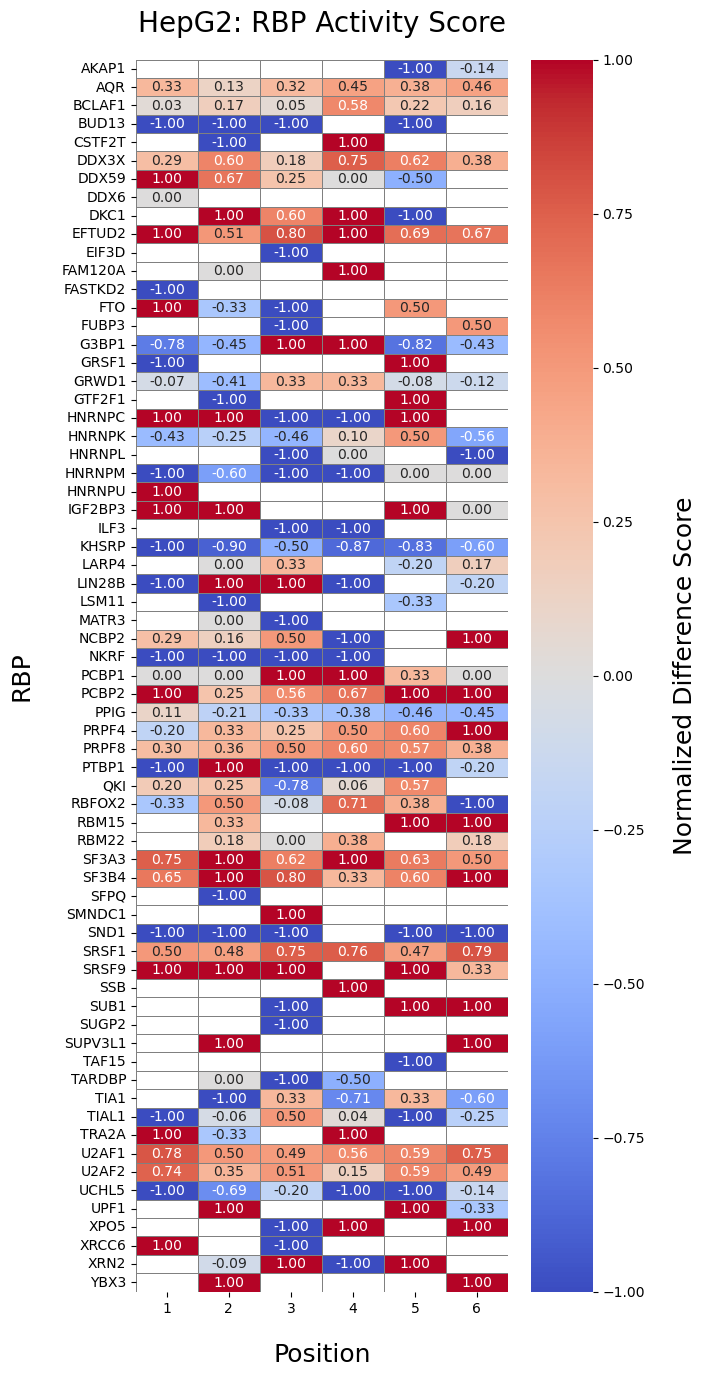

In [13]:
# Making the heatmap

df = pd.DataFrame(results_df)

# Pivot the dataframe to have positions as columns, RBPs as rows, and score as values
heatmap_data = df.pivot(index='RBP', columns='position', values='norm_diff')

# Plot
plt.figure(figsize=(6,16))
ax = sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm",
    center = 0,
    cbar_kws={'label': 'Normalized Difference Score'},
    linewidths=0.5,
    linecolor='gray'
)

cbar = plt.gcf().axes[-1]  # Get colorbar axis
cbar.set_ylabel('Normalized Difference Score', fontsize=18, labelpad=20)

# Axis labels with font size and labelpad
plt.xlabel("Position", fontsize=18, labelpad=20)
plt.ylabel("RBP", fontsize=18, labelpad=20)
plt.title(f"HepG2: RBP Activity Score", fontsize=20, pad=20)
plt.show()

In [ ]:
# Try defining it all as a function

## K562

In [14]:
k562_path = "/project/PlatigLab/users/yogi/backups/2025-08-28_probability_SHAP_with_all_training_UBPs_as_background/FINAL_AVERAGE_SHAP_CACHE/K562_all-data.feather"

k562 = pl.read_ipc(k562_path)

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


In [15]:
# Filter massive dataframe for KD samples, FDR <= 0.05, abs[DeltaPSI] >= 0.05

filtered_k562 = (
    k562
    .filter(
        (k562["Sample Name"].str.contains("KD", literal=True))
        & (k562["FDR"] <= 0.05)
        & (k562["DeltaPSI"].abs() >= 0.05)
    )    
)

# Columns 
columns_to_keep = [
    "RBP_KD_Target",
    "Sample Name",
    "FDR",
    "DeltaPSI",
    "has_RBP_KD_1",
    "has_RBP_KD_2",
    "has_RBP_KD_3",
    "has_RBP_KD_4",
    "has_RBP_KD_5",
    "has_RBP_KD_6",
    "Raw P-Val",
    "rMATS Event ID"
]

In [16]:
# Get all the RBPs that were knocked down to use in for loop

rbp_targets = (
    filtered_k562["RBP_KD_Target"]
    .unique()
    .sort()
    .to_list()
)

print(rbp_targets)

['AARS', 'AATF', 'ABCF1', 'AGGF1', 'AKAP1', 'AKAP8L', 'APOBEC3C', 'AQR', 'BUD13', 'CPEB4', 'CPSF6', 'CSTF2T', 'DDX1', 'DDX24', 'DDX3X', 'DDX47', 'DDX51', 'DDX52', 'DDX55', 'DHX30', 'DROSHA', 'EEF2', 'EFTUD2', 'EIF3G', 'EIF4G2', 'EWSR1', 'FAM120A', 'FASTKD2', 'FMR1', 'FTO', 'FUS', 'FXR1', 'GEMIN5', 'GPKOW', 'GRWD1', 'GTF2F1', 'HLTF', 'HNRNPA1', 'HNRNPC', 'HNRNPK', 'HNRNPL', 'HNRNPM', 'HNRNPU', 'HNRNPUL1', 'IGF2BP2', 'ILF3', 'KHDRBS1', 'KHSRP', 'LARP4', 'LARP7', 'LIN28B', 'LSM11', 'MATR3', 'MBNL1', 'METAP2', 'MTPAP', 'NCBP2', 'NONO', 'NSUN2', 'PABPC4', 'PCBP1', 'PHF6', 'PPIL4', 'PTBP1', 'PUM1', 'PUM2', 'PUS1', 'QKI', 'RBFOX2', 'RBM15', 'RBM22', 'RPS10', 'SAFB2', 'SBDS', 'SERBP1', 'SF3B4', 'SLBP', 'SLTM', 'SMNDC1', 'SND1', 'SRSF1', 'SSB', 'SUPV3L1', 'TAF15', 'TARDBP', 'TBRG4', 'TIA1', 'TROVE2', 'U2AF1', 'U2AF2', 'UCHL5', 'UPF1', 'UTP18', 'UTP3', 'WDR3', 'WDR43', 'WRN', 'XRN2', 'YBX3', 'ZC3H8', 'ZRANB2']


In [17]:
positions = [1,2,3,4,5,6]

results = []  # collect all results here

for rbp in rbp_targets:
    for pos in positions:
        
        rbp_specific_data = (
        filtered_k562
        .filter(
            (pl.col("RBP_KD_Target") == rbp) & (pl.col(f"has_RBP_KD_{pos}") == True))
        .unique(subset=["rMATS Event ID"])) # gets in-silico KD rows per RBP per position
        
        # Drop unneccesary columns
        rbp_specific_data = rbp_specific_data.select(columns_to_keep)
    
        # Convert to pandas
        df = rbp_specific_data.to_pandas()
    
        # Prevents error for no data (SAFB or IGF..1)
        data = df["DeltaPSI"]

        if data.empty:
            continue 
    
        # DPSI conversion
        df["DeltaPSI"] = df["DeltaPSI"] * -1
                
        # Calculate the number of positive dPSI and the number of negative dPSI
         
        num_pos = (df["DeltaPSI"] > 0).sum()
        num_neg = (df["DeltaPSI"] < 0).sum()
        
        # Pseudocount to avoid divison by zero
        alpha = 0.5
        
        # Normalized Difference Score
        norm_diff = (num_pos - num_neg) / (num_pos + num_neg)
            
        # Append results
        results.append({
            "RBP": rbp,
            "position": pos,
            "num_pos": num_pos,
            "num_neg": num_neg,
            "norm_diff": norm_diff
        })

# Final results dataframe
results_df = pd.DataFrame(results)

In [19]:
test = results_df[results_df["RBP"] == "RBFOX2"]
print(test)

        RBP  position  num_pos  num_neg  norm_diff
191  RBFOX2         1        0        1  -1.000000
192  RBFOX2         2        2        0   1.000000
193  RBFOX2         3        4        3   0.142857
194  RBFOX2         4        6        1   0.714286
195  RBFOX2         5        4        0   1.000000


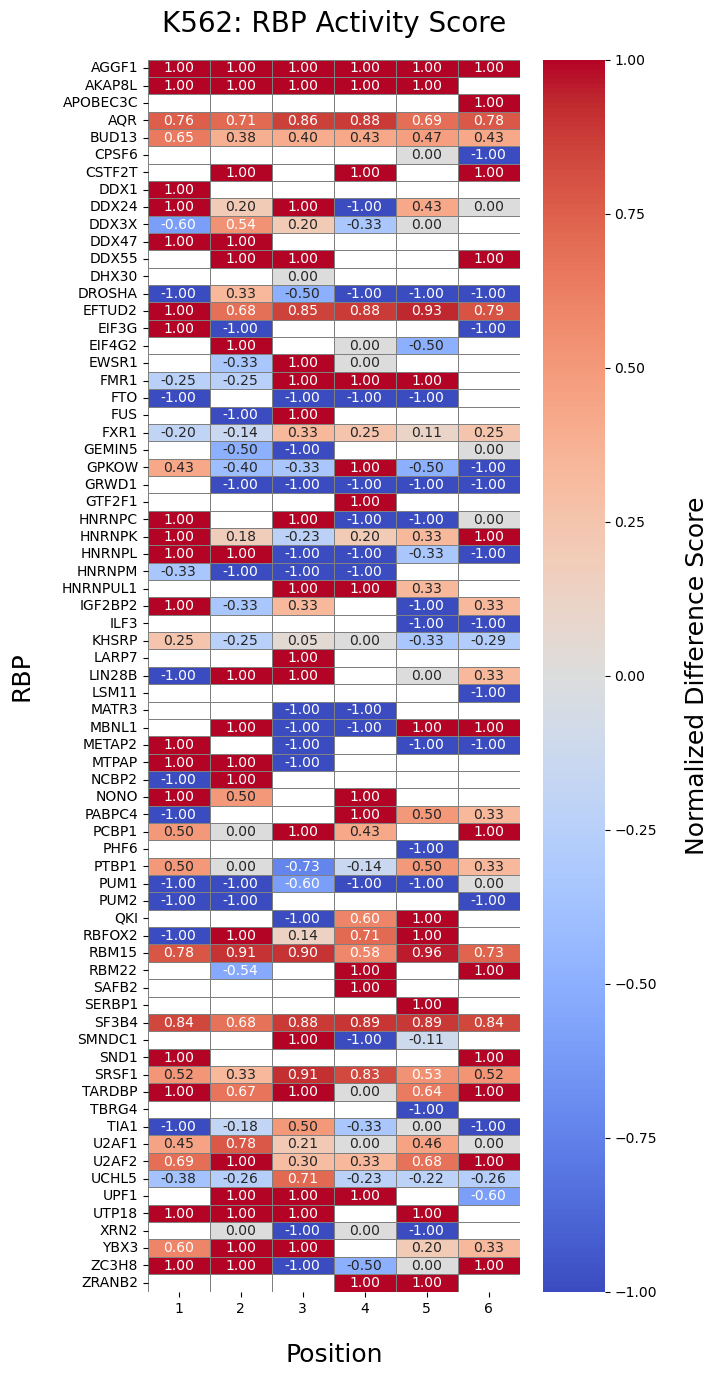

In [20]:
# Making the heatmap

df = pd.DataFrame(results_df)

# Pivot the dataframe to have positions as columns, RBPs as rows, and score as values
heatmap_data = df.pivot(index='RBP', columns='position', values='norm_diff')

# Plot
plt.figure(figsize=(6,16))
ax = sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm",
    center = 0,
    cbar_kws={'label': 'Normalized Difference Score'},
    linewidths=0.5,
    linecolor='gray'
)

cbar = plt.gcf().axes[-1]  # Get colorbar axis
cbar.set_ylabel('Normalized Difference Score', fontsize=18, labelpad=20)

# Axis labels with font size and labelpad
plt.xlabel("Position", fontsize=18, labelpad=20)
plt.ylabel("RBP", fontsize=18, labelpad=20)
plt.title(f"K562: RBP Activity Score", fontsize=20, pad=20)
plt.show()